In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

# 限制单线程运行，防止多线程死锁或资源竞争
torch.set_num_threads(1)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42


sys.version_info(major=3, minor=14, micro=2, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.1
pandas 2.3.3
sklearn 1.8.0
torch 2.10.0+cu130
cuda:0


数据加载

In [2]:
from pathlib import Path

# 根据 day12 的文件布局，数据都在 cifar-10 文件夹下
DATA_DIR = Path("cifar-10")
train_lables_file = DATA_DIR / "trainLabels.csv"
test_csv_file = DATA_DIR / "sampleSubmission.csv"
train_folder = DATA_DIR / "train"
test_folder = DATA_DIR / "test"

# 所有的类别
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck',
]

def parse_csv_file(filepath, folder):
    """Parses csv files into (filename(path), label) format"""
    results = []
    with open(filepath, 'r') as f:
        # 第一行是表头，跳过
        lines = f.readlines()[1:]
    for line in lines:
        image_id, label_str = line.strip('\n').split(',')
        image_full_path = folder / f"{image_id}.png"
        results.append((image_full_path, label_str))
    return results

# 解析对应的文件夹
train_labels_info = parse_csv_file(train_lables_file, train_folder)
test_csv_info = parse_csv_file(test_csv_file, test_folder)

# 打印
import pprint
pprint.pprint(train_labels_info[0:5])
pprint.pprint(test_csv_info[0:5])
print(len(train_labels_info), len(test_csv_info))


[(WindowsPath('cifar-10/train/1.png'), 'frog'),
 (WindowsPath('cifar-10/train/2.png'), 'truck'),
 (WindowsPath('cifar-10/train/3.png'), 'truck'),
 (WindowsPath('cifar-10/train/4.png'), 'deer'),
 (WindowsPath('cifar-10/train/5.png'), 'automobile')]
[(WindowsPath('cifar-10/test/1.png'), 'cat'),
 (WindowsPath('cifar-10/test/2.png'), 'cat'),
 (WindowsPath('cifar-10/test/3.png'), 'cat'),
 (WindowsPath('cifar-10/test/4.png'), 'cat'),
 (WindowsPath('cifar-10/test/5.png'), 'cat')]
50000 300000


In [3]:
# train_df = pd.DataFrame(train_labels_info)
train_df = pd.DataFrame(train_labels_info[0:45000])
valid_df = pd.DataFrame(train_labels_info[45000:])
test_df = pd.DataFrame(test_csv_info)

train_df.columns = ['filepath', 'class']
valid_df.columns = ['filepath', 'class']
test_df.columns = ['filepath', 'class']

print(train_df.head())
print(valid_df.head())
print(test_df.head())

               filepath       class
0  cifar-10\train\1.png        frog
1  cifar-10\train\2.png       truck
2  cifar-10\train\3.png       truck
3  cifar-10\train\4.png        deer
4  cifar-10\train\5.png  automobile
                   filepath       class
0  cifar-10\train\45001.png       horse
1  cifar-10\train\45002.png  automobile
2  cifar-10\train\45003.png        deer
3  cifar-10\train\45004.png  automobile
4  cifar-10\train\45005.png    airplane
              filepath class
0  cifar-10\test\1.png   cat
1  cifar-10\test\2.png   cat
2  cifar-10\test\3.png   cat
3  cifar-10\test\4.png   cat
4  cifar-10\test\5.png   cat


In [4]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class Cifar10Dataset(Dataset):
    df_map = {
        "train": train_df,
        "eval": valid_df,
        "test": test_df
    }
    label_to_idx = {label: idx for idx, label in enumerate(class_names)}
    idx_to_label = {idx: label for idx, label in enumerate(class_names)}

    def __init__(self, mode, transform=None):
        self.df = self.df_map.get(mode, None)
        if self.df is None:
            raise ValueError("mode should be one of train, val, test, but got {}".format(mode))
        self.transform = transform

    def __getitem__(self, index):
        img_path, label = self.df.iloc[index]
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        label = self.label_to_idx[label]
        return img, label

    def __len__(self):
        return self.df.shape[0]


IMAGE_SIZE = 32
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]

transforms_train = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomRotation(40),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

transforms_eval = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

train_ds = Cifar10Dataset("train", transforms_train)
eval_ds = Cifar10Dataset("eval", transforms_eval)

In [5]:
batch_size = 1024
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
eval_dl = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, num_workers=0)

定义模型

In [6]:
class InceptionResBlock(nn.Module):
    def __init__(self, input_channels: int, c1: int, c2: tuple[int, int], c3: tuple[int, int], c4: int):
        super().__init__()
        # Path 1: 1x1 conv + BN
        self.p1_1 = nn.Conv2d(input_channels, c1, kernel_size=1, bias=False)
        self.p1_bn = nn.BatchNorm2d(c1)

        # Path 2: 1x1 conv -> 3x3 conv (+ BN)
        self.p2_1 = nn.Conv2d(input_channels, c2[0], kernel_size=1, bias=False)
        self.p2_bn1 = nn.BatchNorm2d(c2[0])
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1, bias=False)
        self.p2_bn2 = nn.BatchNorm2d(c2[1])

        # Path 3: 1x1 conv -> 5x5 conv (+ BN)
        self.p3_1 = nn.Conv2d(input_channels, c3[0], kernel_size=1, bias=False)
        self.p3_bn1 = nn.BatchNorm2d(c3[0])
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2, bias=False)
        self.p3_bn2 = nn.BatchNorm2d(c3[1])

        # Path 4: 3x3 MaxPool -> 1x1 conv (+ BN)
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(input_channels, c4, kernel_size=1, bias=False)
        self.p4_bn = nn.BatchNorm2d(c4)

        self.out_channels = c1 + c2[1] + c3[1] + c4
        if input_channels != self.out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(input_channels, self.out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(self.out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        p1 = F.relu(self.p1_bn(self.p1_1(x)))
        p2 = F.relu(self.p2_bn2(self.p2_2(F.relu(self.p2_bn1(self.p2_1(x))))))
        p3 = F.relu(self.p3_bn2(self.p3_2(F.relu(self.p3_bn1(self.p3_1(x))))))
        p4 = F.relu(self.p4_bn(self.p4_2(self.p4_1(x))))

        out = torch.cat((p1, p2, p3, p4), dim=1)
        out = out + self.shortcut(x)
        return F.relu(out)


In [7]:
class InceptionNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.Conv2d(64, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 192, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            InceptionResBlock(192, 64, (96, 128), (16, 32), 32),
            InceptionResBlock(256, 128, (128, 192), (32, 96), 64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            InceptionResBlock(480, 192, (96, 208), (16, 48), 64),
            InceptionResBlock(512, 160, (112, 224), (24, 64), 64),
            InceptionResBlock(512, 128, (128, 256), (24, 64), 64),
            InceptionResBlock(512, 112, (144, 288), (32, 64), 64),
            InceptionResBlock(528, 256, (160, 320), (32, 128), 128),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(832, num_classes)
        )
        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.model(x)


In [8]:
#计算总参数量
total_params = sum(p.numel() for p in InceptionNet(len(class_names)).parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")

Total params: 4,631,978


训练

In [9]:
import torch.optim as optim

from sklearn.metrics import accuracy_score

@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    loss_list = []
    pred_list = []
    label_list = []
    for datas, labels in dataloader:
        datas = datas.to(device)
        labels = labels.to(device)
        # 前向计算
        logits = model(datas)
        loss = loss_fct(logits, labels)         # 验证集损失
        loss_list.append(loss.item())

        preds = logits.argmax(axis=-1)    # 验证集预测
        pred_list.extend(preds.cpu().numpy().tolist())
        label_list.extend(labels.cpu().numpy().tolist())

    acc = accuracy_score(label_list, pred_list)
    return np.mean(loss_list), acc


save best

In [10]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        self.save_dir = save_dir
        self.save_step = save_step
        self.save_best_only = save_best_only
        self.best_metrics = -1

        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return

        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



early stop

In [11]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = -1
        self.counter = 0

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric
            self.counter = 0
        else:
            self.counter += 1

    @property
    def early_stop(self):
        return self.counter >= self.patience


In [12]:
# 训练
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    scheduler,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    record_dict = {
        "train": [],
        "val": []
    }

    global_step = 0
    model.train()
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            for datas, labels in train_loader:
                datas = datas.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                logits = model(datas)
                loss = loss_fct(logits, labels)
                loss.backward()
                optimizer.step()
                preds = logits.argmax(axis=-1)

                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
                loss = loss.cpu().item()

                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })

                if global_step % eval_step == 0:
                    model.eval()
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train()

                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})

            scheduler.step()

    return record_dict


epoch = 20

model = InceptionNet(num_classes=10)

loss_fct = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoch)

if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

exp_name = "inception_optimized"
save_ckpt_callback = SaveCheckpointsCallback(f"checkpoints/{exp_name}", save_step=len(train_dl), save_best_only=True)
early_stop_callback = EarlyStopCallback(patience=5)

model = model.to(device)
record = training(
    model,
    train_dl,
    eval_dl,
    epoch,
    loss_fct,
    optimizer,
    scheduler,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=len(train_dl)
    )

  0%|          | 0/880 [00:00<?, ?it/s]

损失，准确率曲线

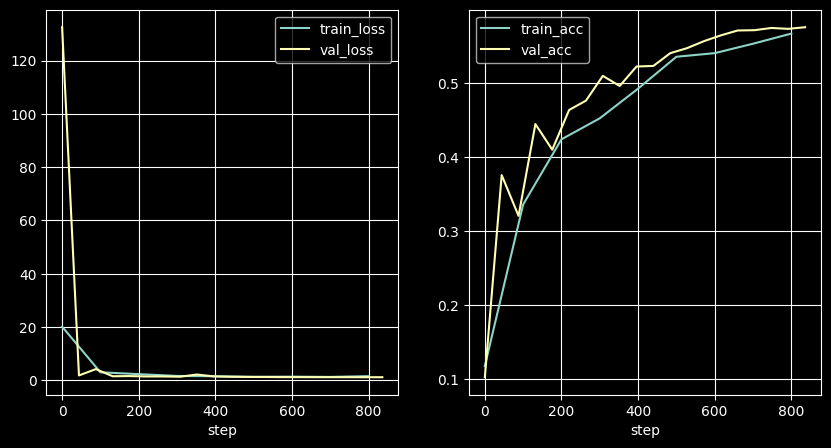

In [13]:
#画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(record_dict, sample_step=500):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # plot
    fig_num = len(train_df.columns)
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid()
        axs[idx].legend()
        # axs[idx].set_xticks(range(0, train_df.index[-1], 5000))
        # axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, train_df.index[-1], 5000)))
        axs[idx].set_xlabel("step")

    plt.show()

plot_learning_curves(record, sample_step=100)  #横坐标是 steps

评估

In [14]:
# dataload for evaluating

# load checkpoints
model.load_state_dict(torch.load(f"checkpoints/{exp_name}/best.ckpt", map_location="cpu"))

model.eval()
loss, acc = evaluating(model, eval_dl, loss_fct)
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     1.1630
accuracy: 0.5750


推理

In [15]:
# test_df
test_ds = Cifar10Dataset("test", transform=transforms_eval)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

preds_collect = []
model.eval()
for data, fake_label in tqdm(test_dl):
    data = data.to(device=device)
    logits = model(data)
    preds = [test_ds.idx_to_label[idx] for idx in logits.argmax(axis=-1).cpu().tolist()]
    preds_collect.extend(preds)

test_df["class"] = preds_collect
test_df.head()

  0%|          | 0/293 [00:00<?, ?it/s]

,filepath,class
0,cifar-10\test\1.png,bird
1,cifar-10\test\2.png,airplane
2,cifar-10\test\3.png,airplane
3,cifar-10\test\4.png,ship
4,cifar-10\test\5.png,airplane


In [16]:
# 导出 submission.csv
test_df.to_csv("submission.csv", index=False)